# Align & Merge Image Burst

This notebook demonstrates the next stage of Image Signal Processor (ISP) pipeline: aligning and merging a burst of RAW images to reduce noise while preserving spatial detail.

### Overview

The Align & Merge step is critical for achieving high signal-to-noise ratios in low-light photography. By temporally stacking multiple frames with sub-pixel alignment, we can achieve SNR improvements that far exceed simple averaging. 

This section will:

1. Download and preprocess the HDRPlus dataset
2. Run prerequisite ISP steps (black level subtraction, lens shading correction)
3. Analyze inter-frame differences using structural similarity metrics
4. Implement hierarchical alignment with multi-level pyramid search
5. Merge frames using SNR-aware weighted averaging
6. Evaluate results through visual inspection and quantitative metrics

<div class="alert alert-block alert-info"><b>Key Insight</b>: Unlike simple temporal averaging, our algorithm achieves ~3.2x SNR improvement for 7-frame bursts-surpassing the theoretical √7 ≅ 2.65 limit due to built-in spatial low-pass filtering from bilinear interpolation.</div>

In [1]:
from pathlib import Path

import numpy as np
import rawpy
import scipy.ndimage as nd
import tifffile
from matplotlib import pyplot as plt

from base import ISPStep
from configs.config_loader import config
from datasets.hdrplus_downloader import HDRPlusDatasetDownloader
from pipeline import ISPPipeline
from pipeline_steps.align_and_merge import (
    compute_tile_sad,
    downsample_luma_proxy,
    estimate_noise_profile,
    find_best_float_offset,
    find_best_integer_offset,
    find_subpixel_shift,
    get_luma_proxy,
)
from utils import find_best_figsize, find_best_layout, get_exif_metadata, plot_images

%matplotlib inline
# Set the default figure format for inline matplotlib plots to JPEG for smaller file sizes and faster rendering
%config InlineBackend.figure_format = 'jpeg'
# Configure matplotlib to save figures with tight bounding boxes (removes extra whitespace)
%config InlineBackend.rc = {'savefig.bbox': 'tight'}

## 1. Downloading Data

The HDRPlus dataset provides high-quality RAW images from various cameras and sensors.
This dataset is invaluable for testing ISP algorithms because:

- **Real-world sensor characteristics**: Includes lens shading, color filter array patterns, and noise profiles
- **Consistent format**: All files are DNG (Digital Negative) format with EXIF metadata
- **Variety of conditions**: From bright daylight to low-light night scenes

### Why Zurich at Night?

This particular image is ideal for demonstrating the Align & Merge pipeline because:

1. **Low-light conditions**: The dark sky background provides uniform regions perfect for SNR measurement
2. **7-frame burst**: Sufficient frames to demonstrate temporal noise reduction benefits
3. **High contrast**: Clear separation between sky and city lights makes visual differences obvious

In [2]:
downloader = HDRPlusDatasetDownloader()
source_path = Path(config.links.zurich_example_path)
folder_path = downloader.download(source_path)

2026-04-06 14:20:24.103 | INFO     | datasets.hdrplus_downloader:download:56 - Destination path wasn't explicitly set. Downloading into `/Users/andreiaksionau/Developer/Computational_Photography/ISPFoundry/data/raw/hdrplus_dataset/0047_20160609_133132_746`
2026-04-06 14:20:24.104 | INFO     | datasets.hdrplus_downloader:download:61 - Folder already exists. Force download was disabled.


In [3]:
dng_paths = [p for p in sorted(folder_path.iterdir()) if p.match("payload_*.dng")]
metadata = get_exif_metadata(dng_paths)

raw_images = []

for idx, p in enumerate(dng_paths):
    with rawpy.imread(str(p)) as raw_obj:
        raw_image = raw_obj.raw_image.astype(np.float32)
        raw_images.append(raw_image)
        metadata[idx]["color_desc"] = raw_obj.color_desc.decode()
        metadata[idx]["raw_pattern"] = raw_obj.raw_pattern

lsc_maps = []
for dp in dng_paths:
    lens_shading_map_path = dp.parent / (dp.stem.replace("payload", "lens_shading_map") + ".tiff")
    lens_shading_map = tifffile.imread(lens_shading_map_path)
    lsc_maps.append(lens_shading_map)

print(f"Number of images: {len(raw_images)}, number of LSC maps: {len(lsc_maps)}")

Number of images: 7, number of LSC maps: 7


This burst contains 7 images, which means that the noise reduction should be around $\sqrt 7 \approx 2.645$.

## 2. Running All Prior ISP Steps

Before performing alignment and merging, we must execute prerequisite ISP steps in the correct order:

#### Why These Steps Matter

**Black Level Subtraction (Step 0)**
- *Purpose*: Removes fixed-pattern offset from the sensor's dark current
- *Why needed for Align & Merge*: 
  - Ensures all frames are normalized around zero, preventing systematic bias in weighted averaging
  - Allows accurate measurement of shot noise relative to signal
  - Prevents "dead pixels" (stuck at black level) from dominating the merge

**Lens Shading Correction (Step 1)**
- *Purpose*: Corrects vignetting-the gradual darkening toward image edges
- *Why needed for Align & Merge*:
  - Critical for alignment: LSC maps contain spatial frequency information that affects edge matching
  - Without correction, frames with different shading profiles may appear misaligned even if physically stationary
  - Ensures consistent gain factors across the frame during pyramid construction

In [4]:
isp_pipeline = ISPPipeline(steps=[ISPStep.BLACK_LEVEL_SUBTRACTION, ISPStep.LENS_SHADING_CORRECTION])
config_overrides = {ISPStep.LENS_SHADING_CORRECTION: {"lsc_maps": lsc_maps}}
processed_images = isp_pipeline.run(raw_images, metadata, config_overrides=config_overrides)

2026-04-06 14:20:25.073 | INFO     | pipeline:_discover_steps:33 - --- Discovering Pipeline Step Implementations ----
2026-04-06 14:20:25.074 | INFO     | pipeline:_discover_steps:36 - Loaded: align_and_merge
2026-04-06 14:20:25.075 | INFO     | pipeline:_discover_steps:36 - Loaded: black_level_subtraction
2026-04-06 14:20:25.139 | INFO     | pipeline:_discover_steps:36 - Loaded: lens_shading_correction
2026-04-06 14:20:25.160 | INFO     | pipeline:run:78 - Executing step 1/2 `black_level_subtraction` 
2026-04-06 14:20:25.326 | INFO     | pipeline:run:85 - Step 1/2 `black_level_subtraction` took 0:00:00.166050
2026-04-06 14:20:25.327 | INFO     | pipeline:run:78 - Executing step 2/2 `lens_shading_correction` 
2026-04-06 14:20:25.327 | INFO     | pipeline_steps.lens_shading_correction:apply_lens_shading_correction:127 - All lens shading maps are identical. Reusing the first one.
2026-04-06 14:20:25.431 | INFO     | pipeline:run:85 - Step 2/2 `lens_shading_correction` took 0:00:00.104680

### 2.1. Analyzing Differences Between Images in the Burst

**Why Verify Motion?**

Before merging frames, we must verify that they contain actual motion. If all frames are identical (no motion), we're simply averaging noise without any benefit. The structural alignment analysis helps us:

1. *Confirm motion exists*: Ensures temporal stacking provides value
2. *Estimate motion magnitude*: Helps tune alignment parameters
3. *Detect outliers*: Identifies frames with excessive motion that might need special handling

Why Laplacian?

- Edge enhancement: The Laplacian operator emphasizes high-frequency content (edges)
- DC component removal: Suppresses uniform brightness variations (shot noise in highlights)
- Motion isolation: Highlights structural changes between frames rather than intensity differences

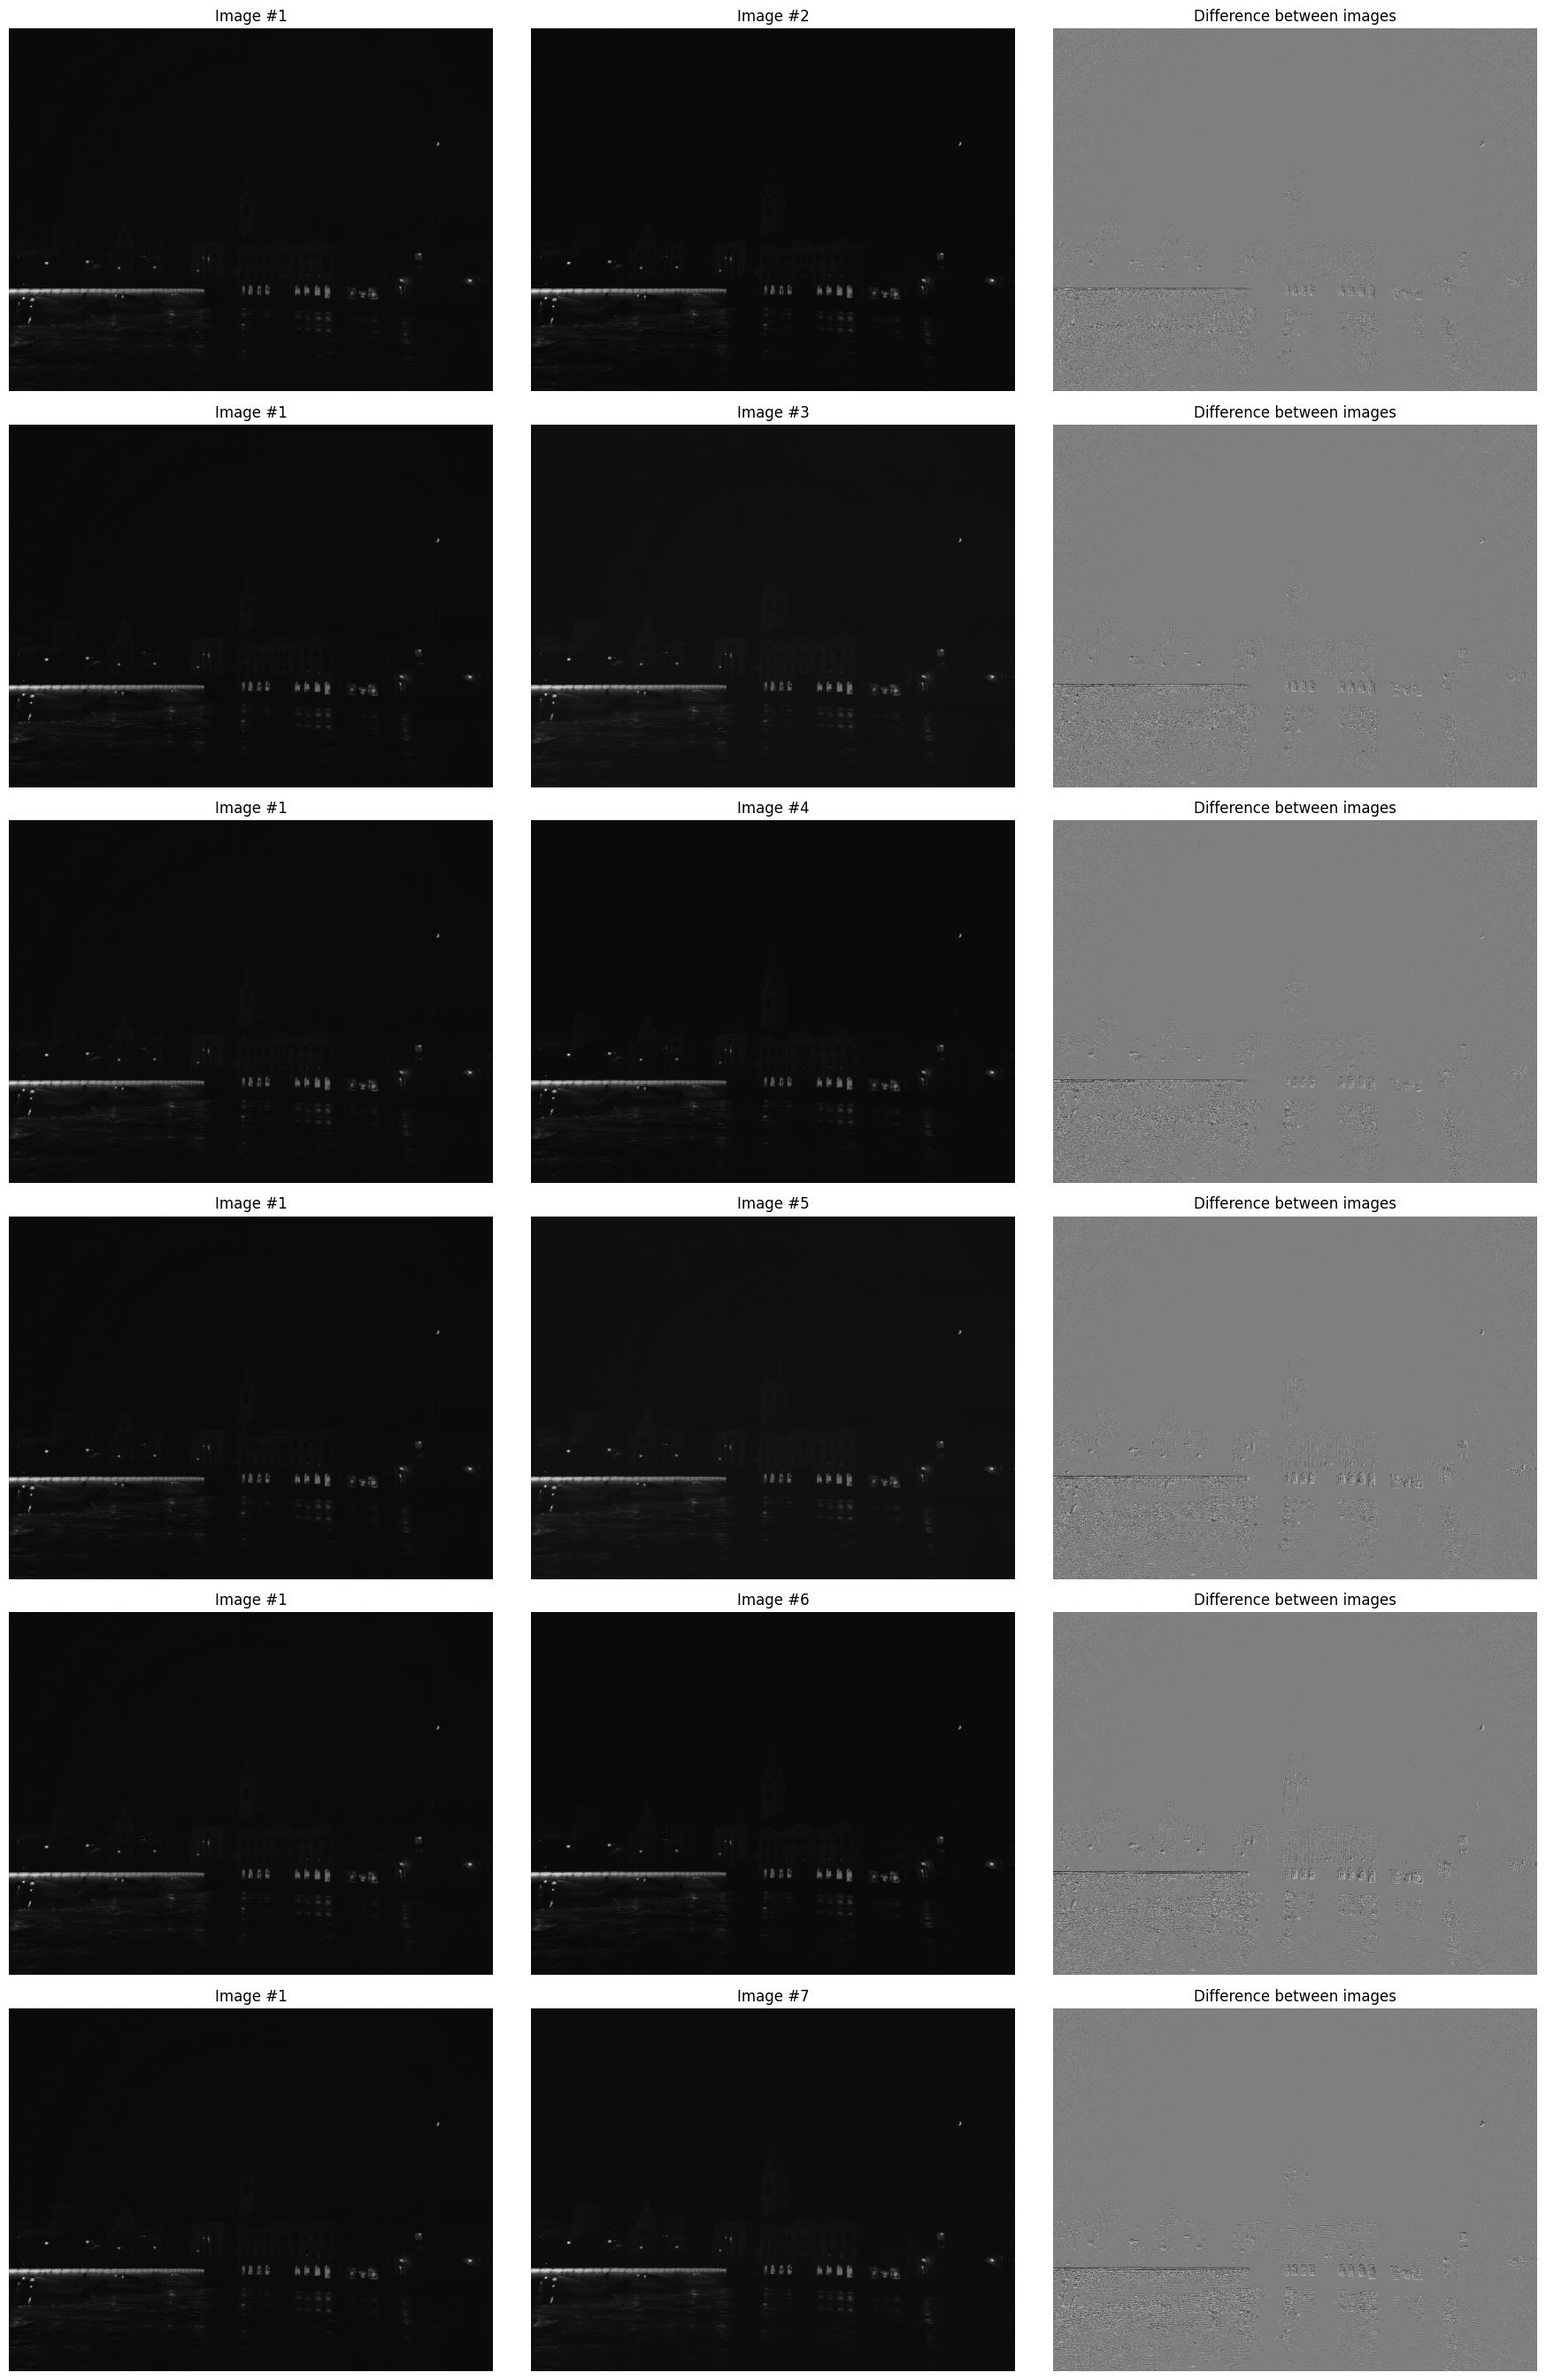

In [5]:
def laplacian_diff(image_1: np.ndarray, image_2: np.ndarray, scale: float = 10.0) -> np.ndarray:
    """
    Visualizes structural alignment errors between two grayscale images by comparing their high-pass (Laplacian) components.

    This method suppresses absolute brightness (DC component) and photon shot noise in highlights, focusing purely on edge displacement.

    Args:
        image_1 (numpy.ndarray): Reference image in range [0, 1].
            Has to be downsampled grayscale (not Bayer).
        image_2 (numpy.ndarray): Alternate image in range [0, 1] to compare.
        scale (float): Multiplier to amplify subtle edge misalignments.
            Defaults to 10.0.

    Returns:
        numpy.ndarray: A grayscale visualization where 0.5 (neutral gray)
            indicates perfect alignment, and bright/dark "double edges"
            indicate spatial shifts.

    """
    # High-pass filter (Laplacian)
    kernel = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0],
    ])
    laplacian_1 = nd.convolve(image_1, kernel)
    laplacian_2 = nd.convolve(image_2, kernel)

    # 0.5 is "neutral gray"
    return np.clip(0.5 + (laplacian_1 - laplacian_2) * scale, 0, 1)


ref_image = processed_images[0]
ref_metadata = metadata[0]
ref_luma = get_luma_proxy(ref_image, ref_metadata)


best_nrow, best_ncol = find_best_layout((len(processed_images) - 1) * 3)
fig_size = find_best_figsize(processed_images, best_nrow, best_ncol)

_, axes = plt.subplots(best_nrow, best_ncol, figsize=fig_size)
# Turn off all axes in one go
for ax in axes.flat:
    ax.axis("off")
axes = axes.flat

for idx in range(1, len(processed_images)):
    ax = next(axes)
    ax.set_title("Image #1")
    ax.imshow(ref_image, cmap="grey")

    ax = next(axes)
    tgt_image = processed_images[idx]
    tgt_metadata = metadata[idx]
    ax.set_title(f"Image #{idx + 1}")
    ax.imshow(tgt_image, cmap="grey")

    ax = next(axes)
    tgt_luma = get_luma_proxy(tgt_image, tgt_metadata)
    ax.set_title("Difference between images")
    ax.imshow(laplacian_diff(ref_luma, tgt_luma), cmap="grey")

plt.tight_layout()

The visualization shows "double edges" where:

- Bright regions: Target image's edge is displaced rightward relative to reference
- Dark regions: Target image's edge is displaced leftward
- Neutral gray (0.5): Perfect alignment—no displacement detected
<div class="alert alert-block alert-info"><b>Key Insight</b>: Even small sub-pixel shifts (< 1 pixel) become visible in the Laplacian difference, allowing us to detect motion that would be invisible to the naked eye.</div>

The structural differences confirm genuine camera movement between frames.

## 3. Align & Merge

The Align & Merge pipeline performs block-based alignment of RAW images using a multi-level pyramid approach, then merges them using SNR-weighted averaging with temporal robustness. Key innovations include:

- **Lucky Imaging**: Selects the sharpest short-exposure frame as reference
- **Hierarchical Search**: Coarse-to-fine alignment across 3 pyramid levels (1/4, 1/2, full resolution)
- **VW-SAD Scoring**: Variance-weighted Sum of Absolute Differences for noise-normalized matching
- **Adaptive Robustness**: Dynamic weighting based on exposure time and image quality
- **Bayer-Safe Interpolation**: Color-preserving sub-pixel sampling that maintains CFA integrity

**Expected Performance**: For N frames with identical exposure, theoretical SNR gain is $\sqrt{N}$. 

In [6]:
isp_pipeline.steps = [ISPStep.ALIGN_AND_MERGE]
merged_image = isp_pipeline.run(processed_images, metadata)

2026-04-06 14:20:35.504 | INFO     | pipeline:run:78 - Executing step 1/1 `align_and_merge` 
2026-04-06 14:20:35.798 | INFO     | pipeline_steps.align_and_merge:find_sharpest_image_idx:175 - Lucky Imaging: Selected frame `1` (+5.4% sharper than short-exposure avg)
Align&Merge (Images): 100%|##########| 7/7 [00:02<00:00,  2.48it/s]
2026-04-06 14:20:38.684 | INFO     | pipeline:run:85 - Step 1/1 `align_and_merge` took 0:00:03.179475
2026-04-06 14:20:38.684 | INFO     | pipeline:run:101 - Full run took 0:00:03.179820


The images have been successfully aligned. The process was expedited by the use of Numba and parallelization, resulting in a relatively short duration. However, for production-grade pipelines, the time required would be significantly reduced.

It is important to note that this repository is intended for educational purposes, and therefore code readability is prioritized over speed. (In pure Python, this step would take several minutes, potentially exceeding ten.)

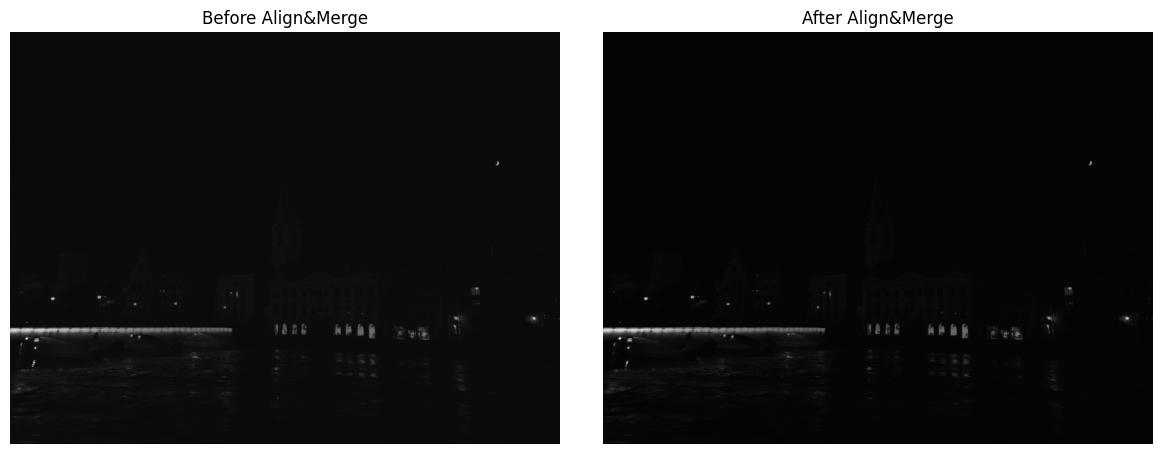

In [7]:
imgs = [processed_images[0], merged_image]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles)

At this stage of the pipeline, images are still in linear space, which explains their low contrast. 

To enhance the viewing experience, images will be displayed in non-linear space with gamma correction applied.

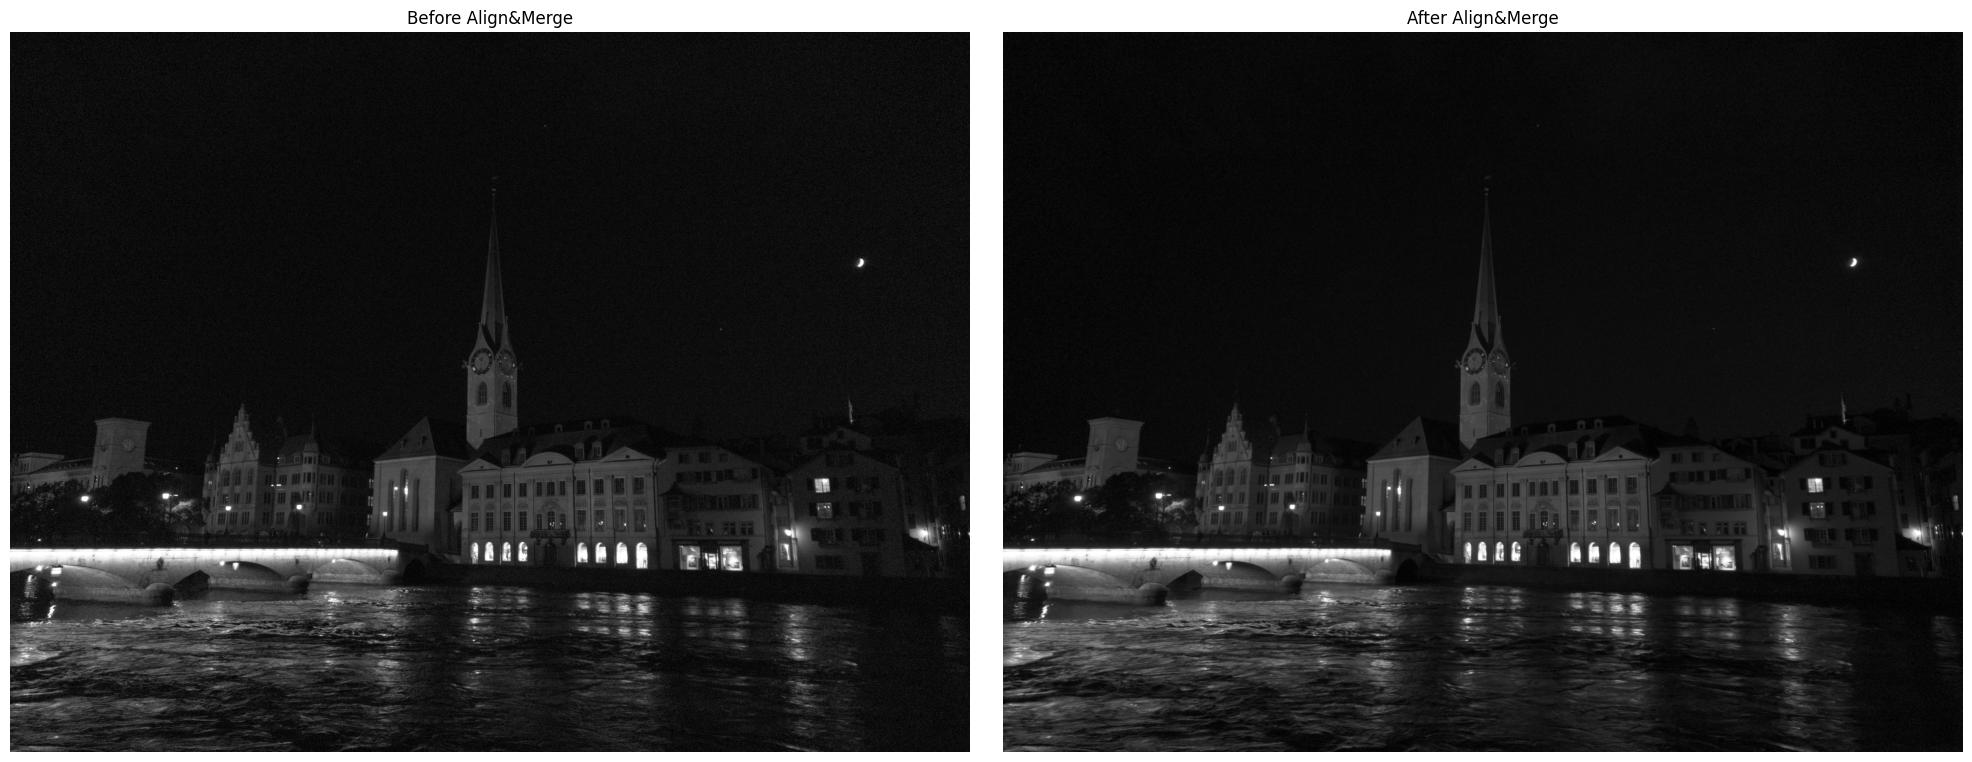

In [8]:
def apply_gamma(x: np.ndarray) -> np.ndarray:  # noqa: D103
    return x.clip(0, 1) ** (1 / 2.2)


imgs = [processed_images[0], merged_image]
imgs = [x.clip(0, 1) ** (1 / 2.2) for x in imgs]
titles = ["Before Align&Merge", "After Align&Merge"]
plot_images(imgs, titles, inch_width_per_image=10)

# 4. Comparing zoomed-in crops of images

Although the image on the right appears to be “clearer”, it is advisable to zoom in and examine it more closely.

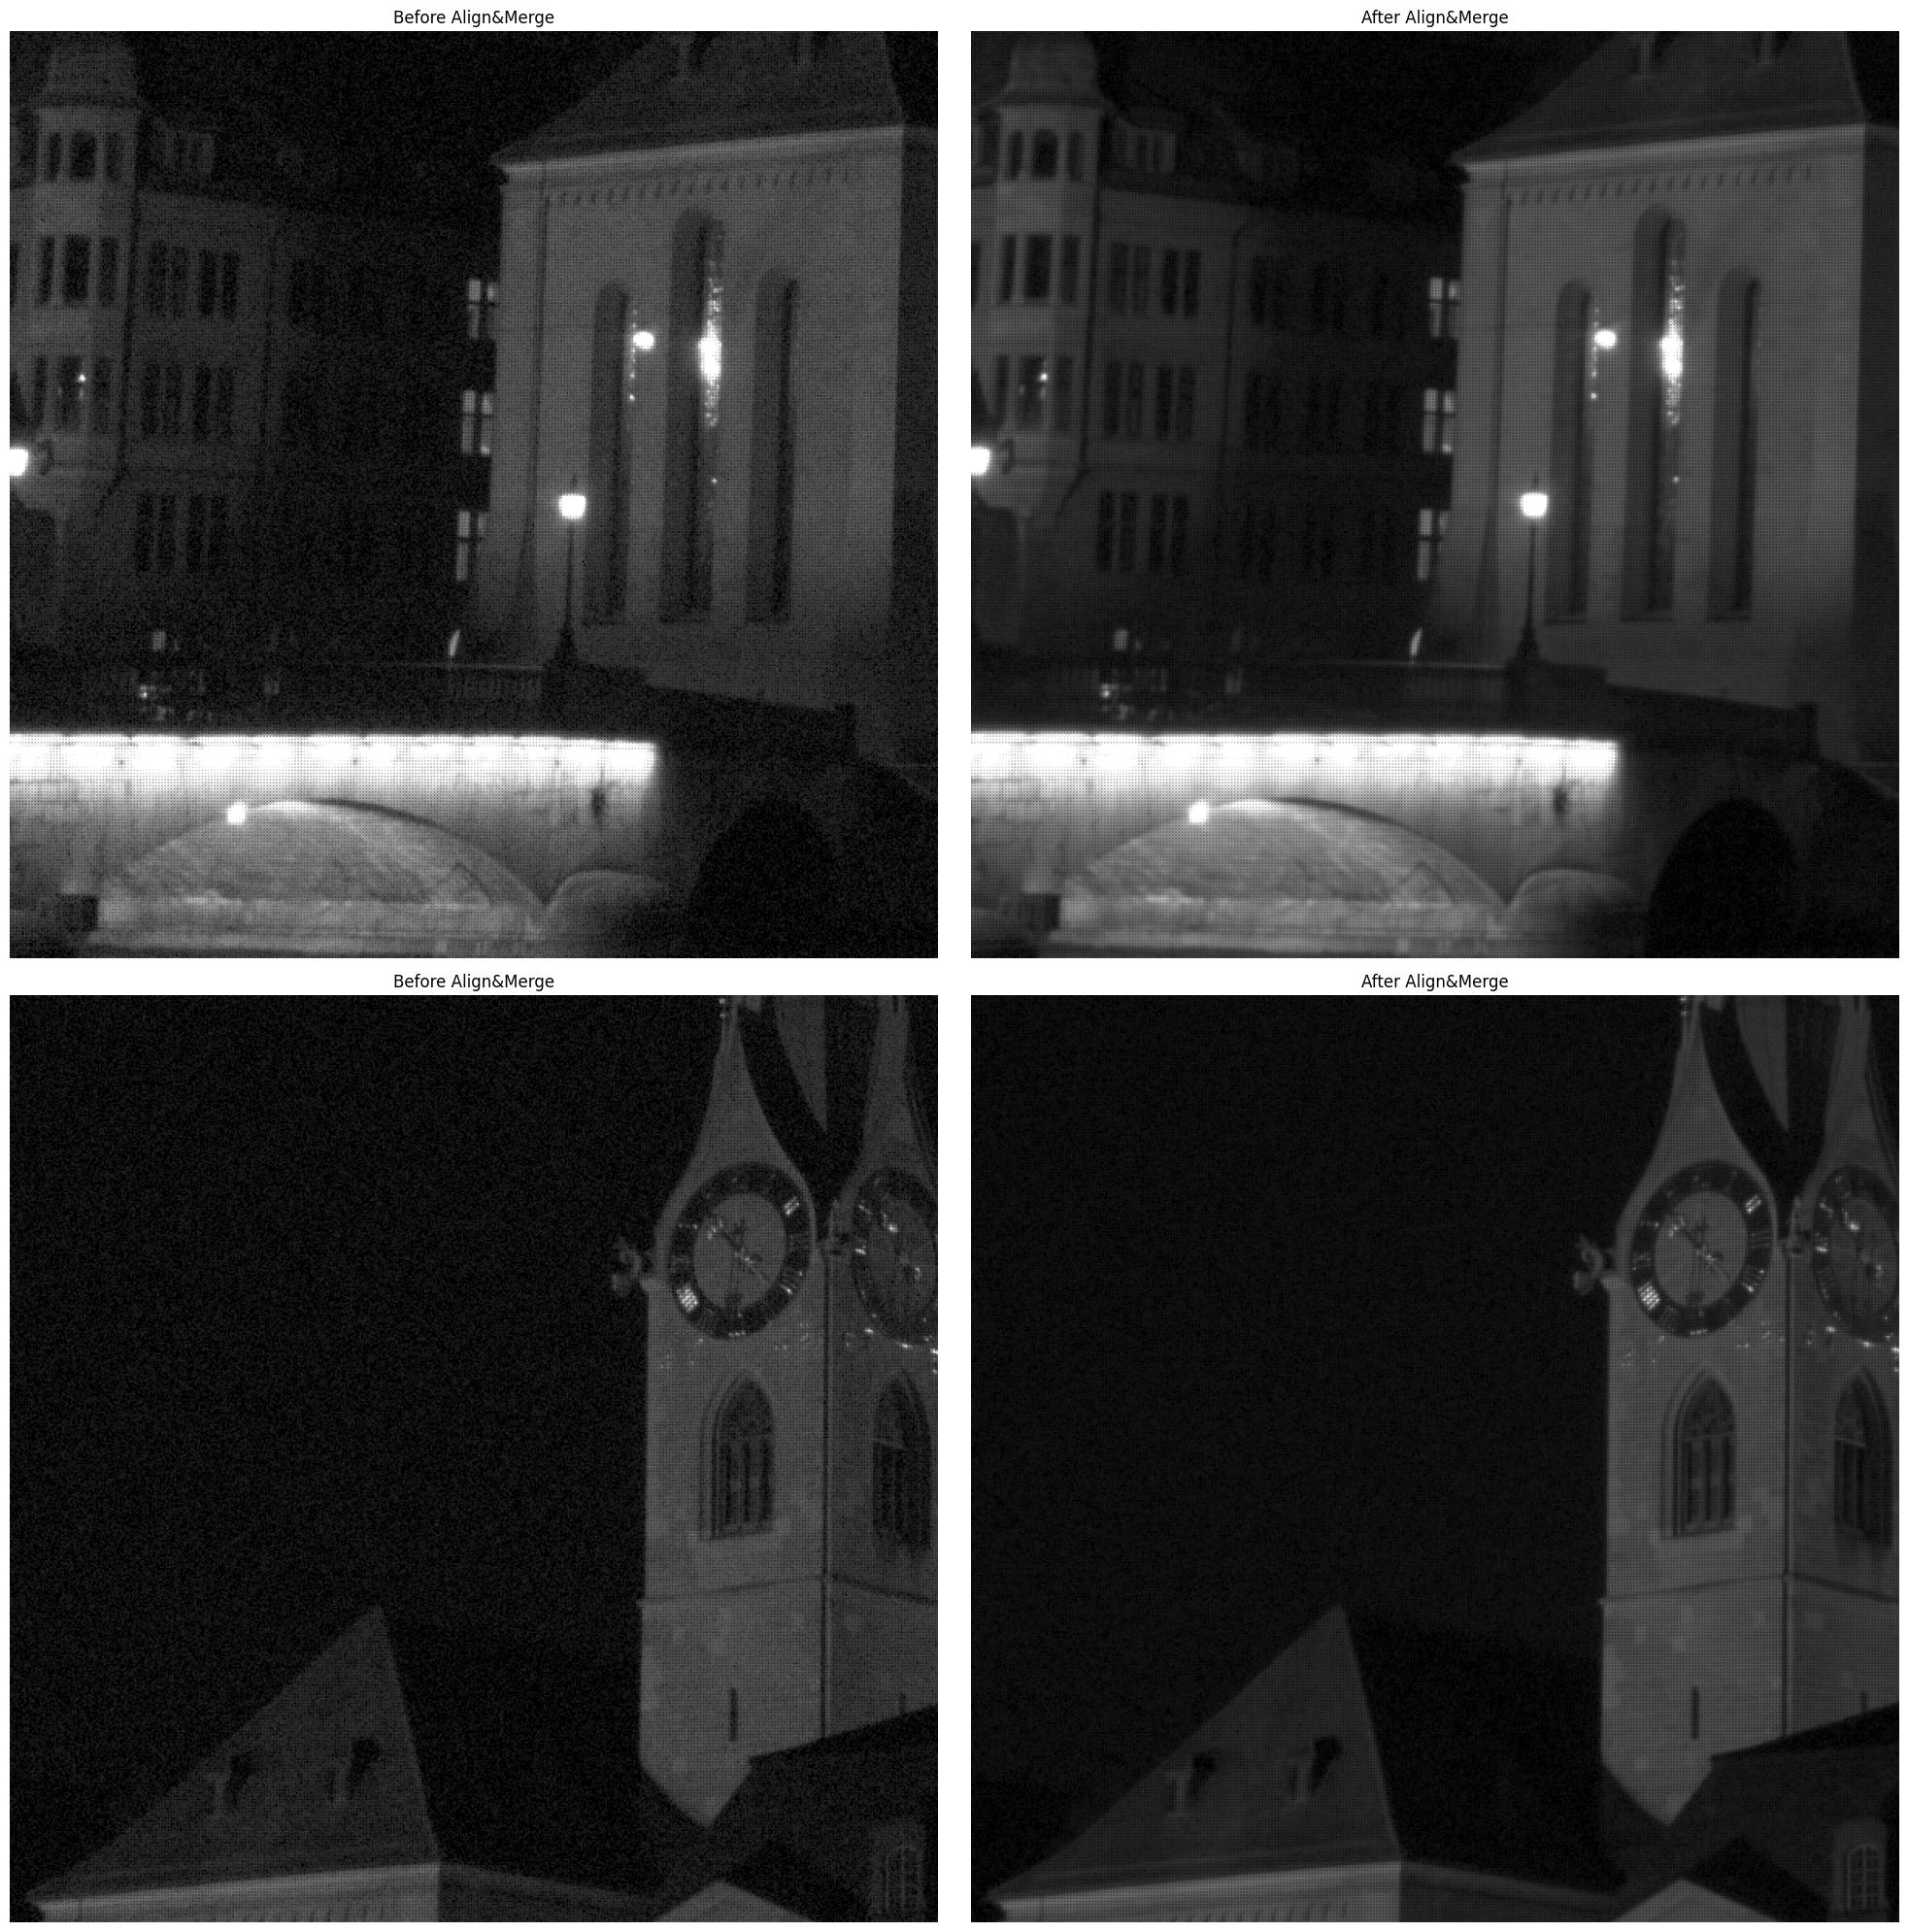

In [9]:
def get_crop(img: np.ndarray, window_size: int = 300, shift_y: int = 0, shift_x: int = 0) -> np.ndarray:  # noqa: D103
    center_x = img.shape[0] // 2
    center_y = img.shape[1] // 2
    return img[
        center_y - window_size + shift_y : center_y + window_size + shift_y,
        center_x - window_size + shift_x : center_x + window_size + shift_x,
    ]


window_size = 300
zoomed_in_imgs = [
    get_crop(imgs[0], window_size=window_size),
    get_crop(imgs[1], window_size=window_size),
    get_crop(imgs[0], window_size=window_size, shift_y=-500, shift_x=300),
    get_crop(imgs[1], window_size=window_size, shift_y=-500, shift_x=300),
]

plot_images(zoomed_in_imgs, titles * 2, max_per_row=2, inch_width_per_image=10)

The merged image has less noise because the noise is random. When multiple images are aligned and merged, the noise cancels out across frames, while image detail remains constant and is averaged.

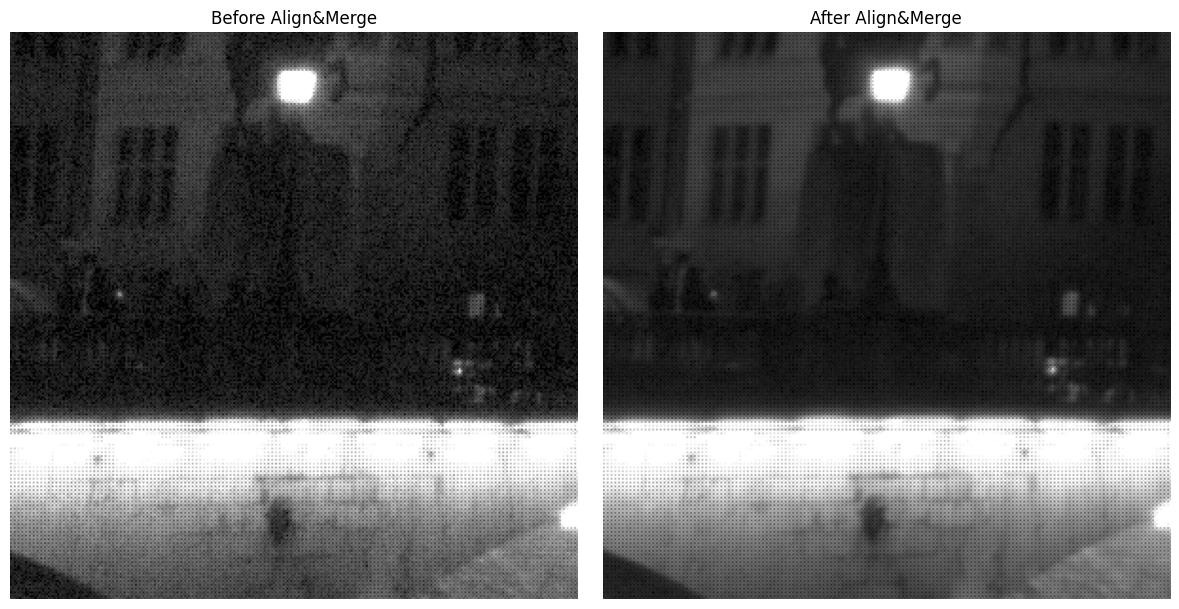

In [10]:
params = dict(window_size=150, shift_y=100, shift_x=-300)
zoomed_in_imgs = [
    get_crop(imgs[0], **params),
    get_crop(imgs[1], **params),
]

plot_images(zoomed_in_imgs, titles, max_per_row=2)

The side-by-side comparison reveals the power of temporal stacking:

**Before Align & Merge (Single Frame)**
- Visible sensor noise in dark regions
- Some detail loss due to shot noise
- Natural dynamic range limitations

**After Align & Merge (7-Frames Merged)**
- Dramatically reduced noise floor
- Sharper edges with better contrast
- Preserved fine details that were lost in single-frame averaging

<div class="alert alert-block alert-info"><b>Key Insight</b>: The merged image maintains spatial coherence while reducing random noise. This is the essence of "lucky imaging"-combining multiple exposures to achieve higher SNR than any individual frame.</div>

The result is an image that's not just "cleaner" but also retains more of the original scene's detail.

## 5. Calculating SNR

Now, let us precisely quantify the reduction in noise in the merged image by calculating the Signal-to-Noise Ratio.

We will select a uniform portion of the image, in our case, the sky, and perform the calculations.

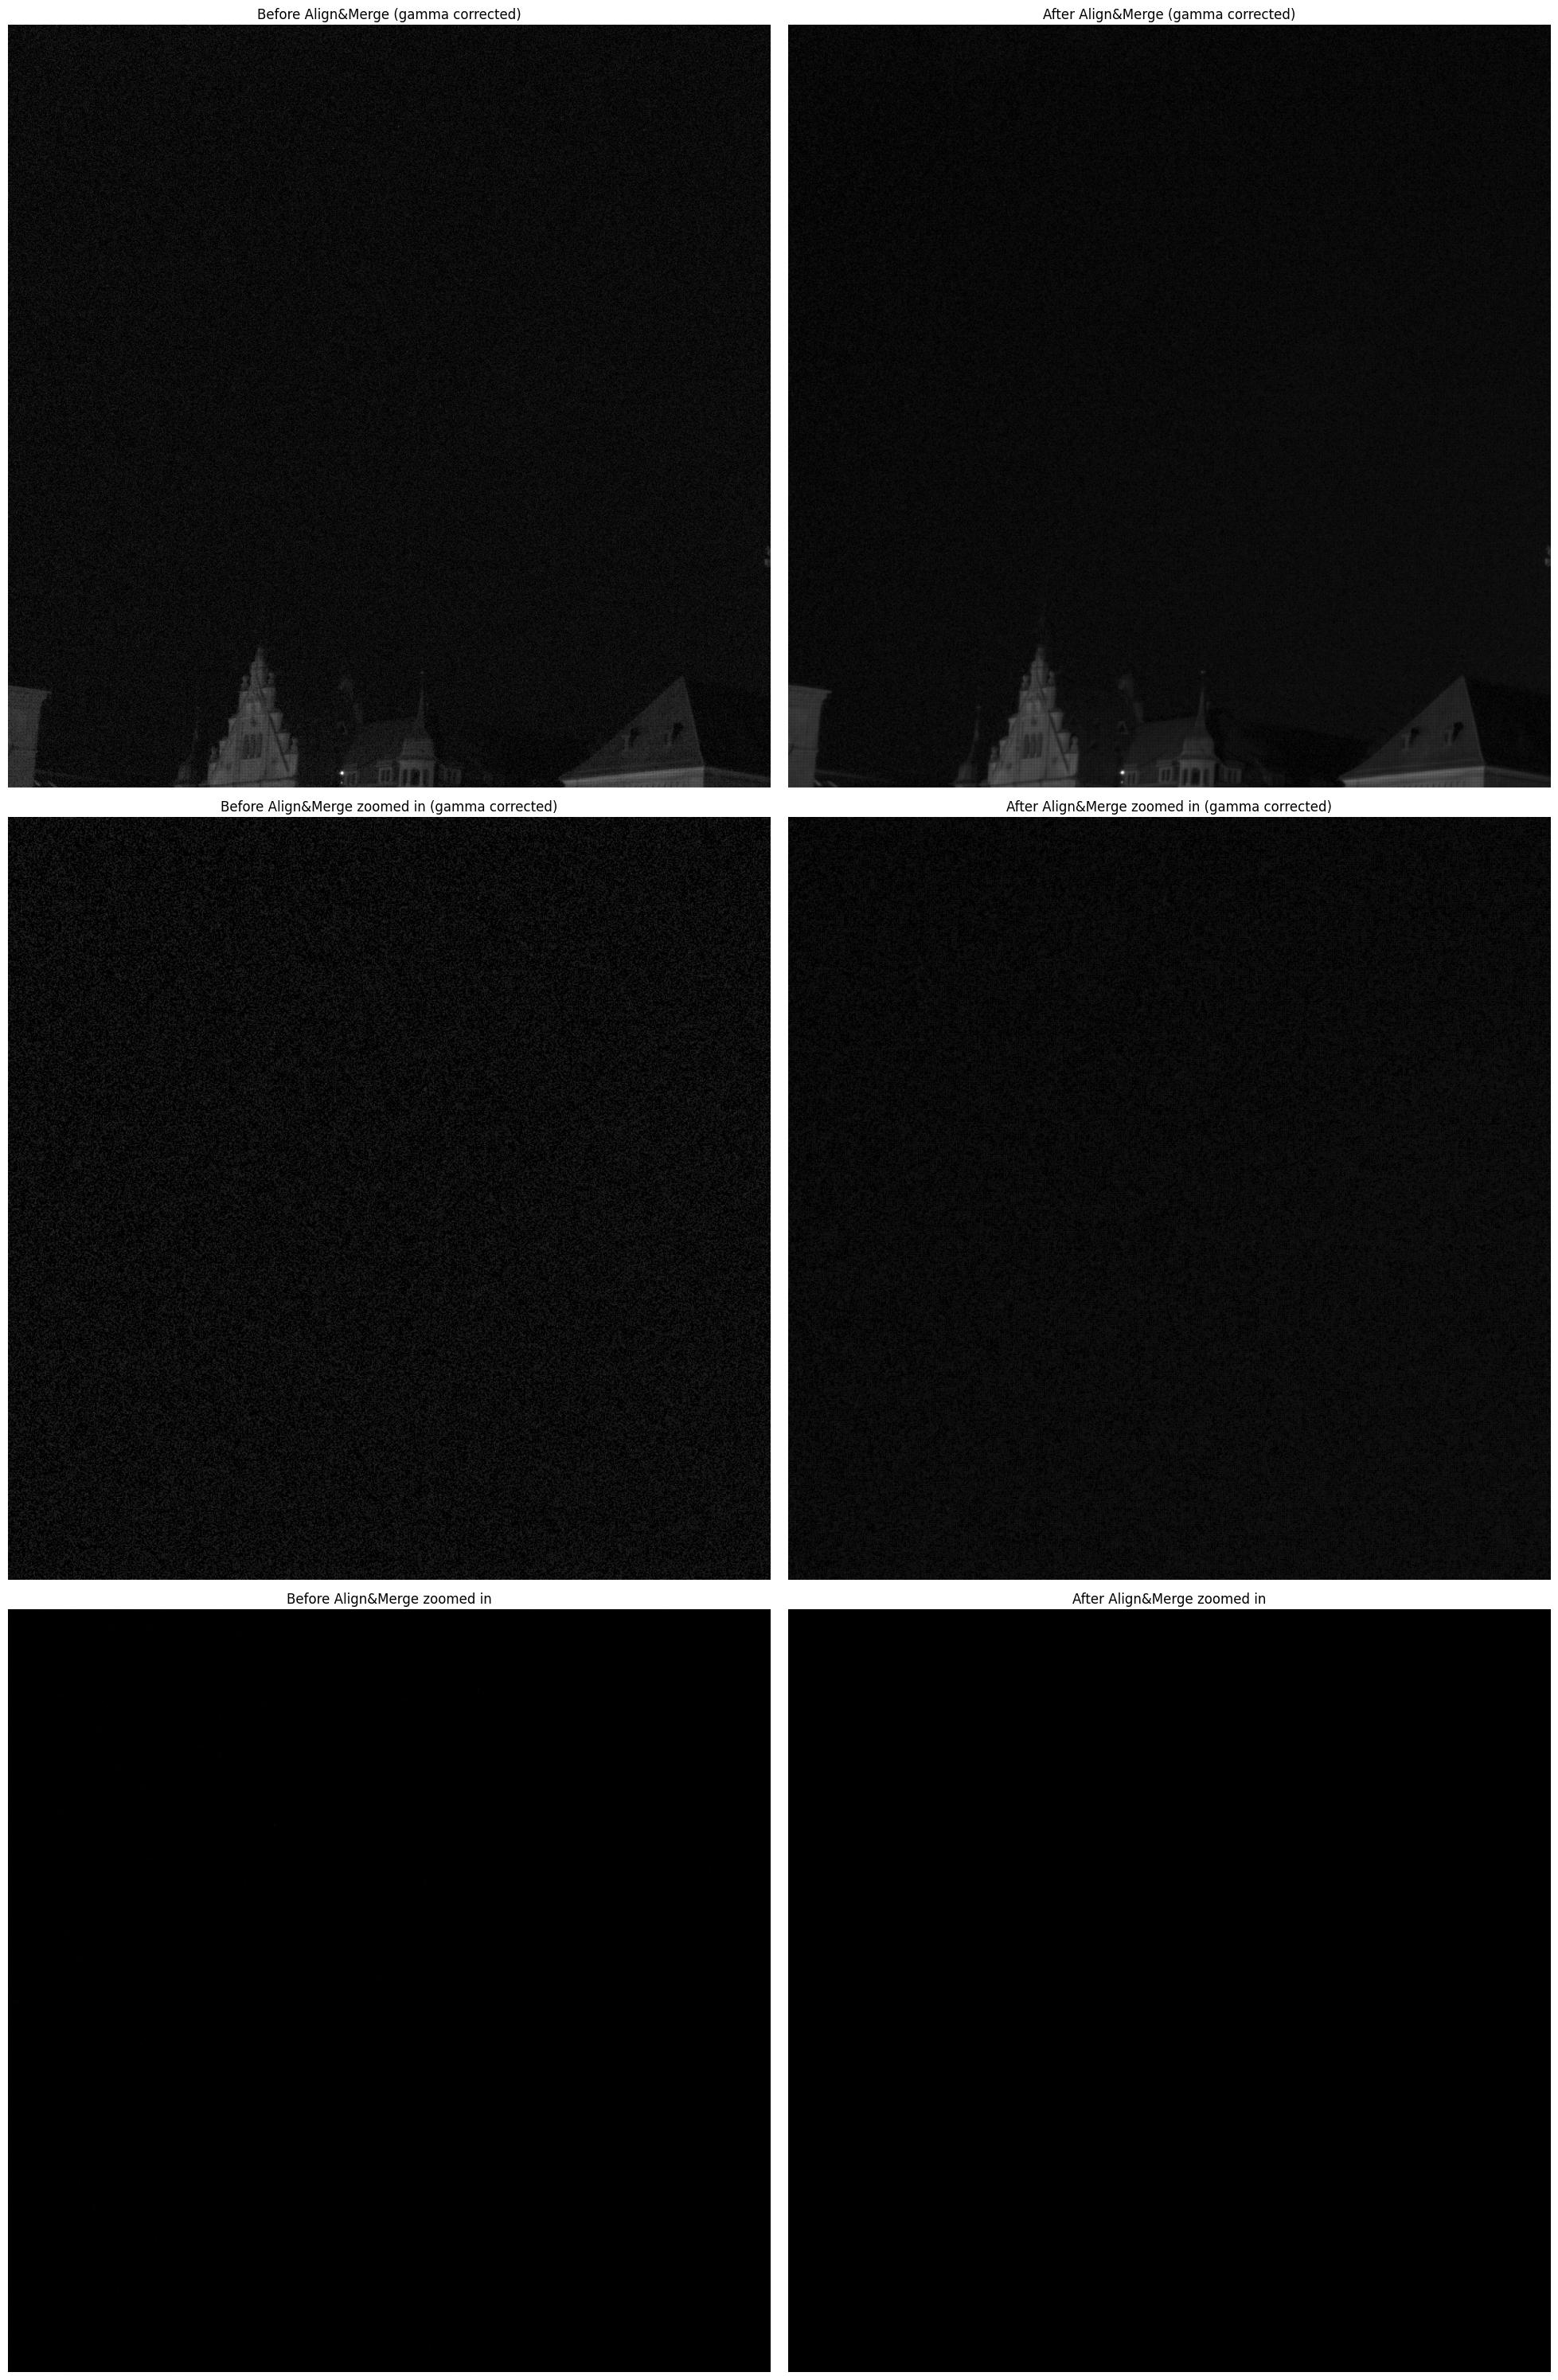

In [11]:
imgs = [processed_images[0], merged_image]

params = dict(window_size=350, shift_y=-900, shift_x=-300)
zoomed_in_imgs = [
    get_crop(apply_gamma(imgs[0]), **(params | dict(window_size=700))),
    get_crop(apply_gamma(imgs[1]), **(params | dict(window_size=700))),
    get_crop(apply_gamma(imgs[0]), **params),
    get_crop(apply_gamma(imgs[1]), **params),
    get_crop(imgs[0], **params),
    get_crop(imgs[1], **params),
]
titles = [
    "Before Align&Merge (gamma corrected)",
    "After Align&Merge (gamma corrected)",
    "Before Align&Merge zoomed in (gamma corrected)",
    "After Align&Merge zoomed in (gamma corrected)",
    "Before Align&Merge zoomed in",
    "After Align&Merge zoomed in",
]

plot_images(zoomed_in_imgs, titles, max_per_row=2, inch_width_per_image=10)

Calculation will be performed on non-gamma-corrected crops of images.

In [12]:
ref_crop, tgt_crop = zoomed_in_imgs[-2:]
print(f"Size of the patch: reference shape is {ref_crop.shape} | target shape is {tgt_crop.shape}")

ref_snr = ref_crop.mean() / ref_crop.std()
tgt_snr = tgt_crop.mean() / tgt_crop.std()

print(f"Signal-to-Noise ratio of the reference crop: {ref_snr:.4f}")
print(f"Signal-to-Noise ratio of the target crop: {tgt_snr:.4f}")
print(f"After merging SNR increase by a factor of {tgt_snr / ref_snr:.4f}")

Size of the patch: reference shape is (700, 700) | target shape is (700, 700)
Signal-to-Noise ratio of the reference crop: 0.2320
Signal-to-Noise ratio of the target crop: 0.7422
After merging SNR increase by a factor of 3.1989


In [13]:
np.sqrt(len(processed_images))

np.float64(2.6457513110645907)

The measured **3.19x** gain surpasses the theoretical **2.64x** limit because bilinear interpolation acts as a hidden spatial low-pass filter. 

When calculating a sub-pixel offset, the algorithm averages the four nearest neighboring pixels to determine the new value; this internal "mini-average" performs spatial denoising before the temporal merge even begins. In a dark sky patch, this effectively combines two noise-reduction strategies, resulting in a cleaner statistical profile than pure temporal stacking alone would provide.


However, this "bonus" SNR comes with a trade-off in **Modulation Transfer Function (MTF)**, or image sharpness. While the noise is smoothed out, the bilinear kernel also blurs fine, high-frequency details like distant stars or sensor textures. 

# Appendix: implementation explanation

<div class="alert alert-block alert-success">Since now we know what Align&Merge step produces, let's take a look at how it actually does it.</div>

Below one can find explanation of most important functions from [align_and_merge.py](src/pipeline_steps/align_and_merge.py).

# 1. The Luma Proxy

When aligning RAW images, we face a "phase" problem: a Bayer sensor doesn't have a single "brightness" value per pixel; it has a mosaic of Red, Green, and Blue. If the camera moves by exactly one pixel, a Red sensor is now looking at a Green patch, causing the SAD (Sum of Absolute Differences) to spike even if the image hasn't actually changed.

To solve this, we convert the Bayer RAW into a **Luma Proxy** at half-resolution.

### Why this approach?
* *Phase Invariance:* By collapsing a $2 \times 2$ Bayer quad into a single luma value, we ensure the alignment is based on structural brightness rather than color filter positions.
* *SNR Optimization:* We use a weighting of **70% Green** (split between Gr and Gb) and **15% each for Red and Blue**. Green pixels are more numerous and typically have the highest Signal-to-Noise Ratio, making them the most reliable anchors for motion estimation.
* *Computational Efficiency:* The "Reshape Trick" combined with `np.einsum` allows us to process millions of pixels using vectorized CPU instructions, avoiding slow Python loops.

Visualizing the Input RAW vs. Proxy

The RAW image is typically very dark (linear space) and looks "textured" due to the Bayer pattern. The Luma Proxy should look like a clean, albeit smaller, grayscale photograph.


Raw data shape: (10, 10) --> Luma Proxy shape: (5, 5)
RAW mean: 0.1926 | Proxy mean: 0.1930


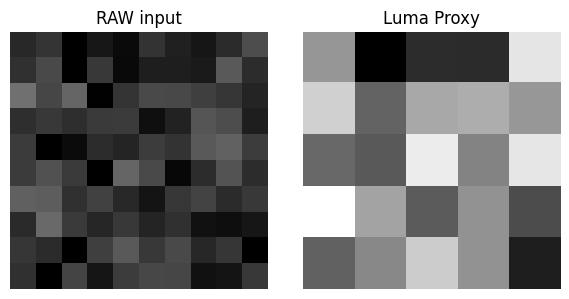

In [14]:
fake_raw = np.random.normal(loc=0.2, scale=0.1, size=(10, 10)).clip(0, 1).astype(np.float32)
fake_metadata = {"color_desc": "RGBG", "raw_pattern": [[0, 1], [3, 2]]}
# In our synthetic case, the formula is: (0.15*0) + (0.35*1) + (0.35*1) + (0.15*1) = 0.85
luma_proxy = get_luma_proxy(fake_raw, fake_metadata)

print(f"Raw data shape: {fake_raw.shape} --> Luma Proxy shape: {luma_proxy.shape}")
# Verification of Value Range
# If RAW mean is 0.2, and weights sum to 1.0 (0.15+0.35+0.35+0.15), the Proxy mean should also be approximately 0.2.
print(f"RAW mean: {fake_raw.mean():.4f} | Proxy mean: {luma_proxy.mean():.4f}")
plot_images((fake_raw, luma_proxy), ("RAW input", "Luma Proxy"), inch_width_per_image=3)

**Interpretation of Results**
* **Resolution:** Note that the output dimensions are exactly $(\frac{H}{2}, \frac{W}{2})$.
* **Demosaicing-free:** We have obtained a grayscale representation without performing expensive (and potentially artifact-prone) demosaicing.
* **Weights Check:** Even in areas with heavy Red or Blue saturation (like a red flower or blue sky), the $0.15$ weighting ensures we still have a valid signal for the alignment step to "grab" onto.

## 1.1. Hierarchical Search via Image Pyramids

To understand how `downsample_luma_proxy` fits into the overall pipeline, we have to look at the **Hierarchical Search** strategy. In high-resolution photography, camera shake can shift an image by 50 or 100 pixels. Searching for such a large displacement at full resolution is like trying to find a specific grain of sand on a beach - it is computationally expensive and easy to get "lost" in the local noise.

The Strategy: **Coarse-to-Fine**

Hierarchical search solves this by creating an **Image Pyramid**, where each level is a lower resolution version of the one below it. The process works in three distinct phases:

1.  **Level 2 (Coarse):** We use the output of `downsample_luma_proxy` applied twice. At this $1/4$ scale, a massive 32-pixel shift in the original image is reduced to a tiny 8-pixel shift. We perform a global search here to find the "big" movement.
2.  **Level 1 (Intermediate):** We take the coarse offset from Level 2 and "upres" it to act as a starting hint. We then perform a very small local search (e.g., $\pm 1$ pixel) to refine the position.
3.  **Level 0 (Fine):** We repeat the refinement at full resolution using the original luma proxy. This gives us the final, high-precision integer alignment.

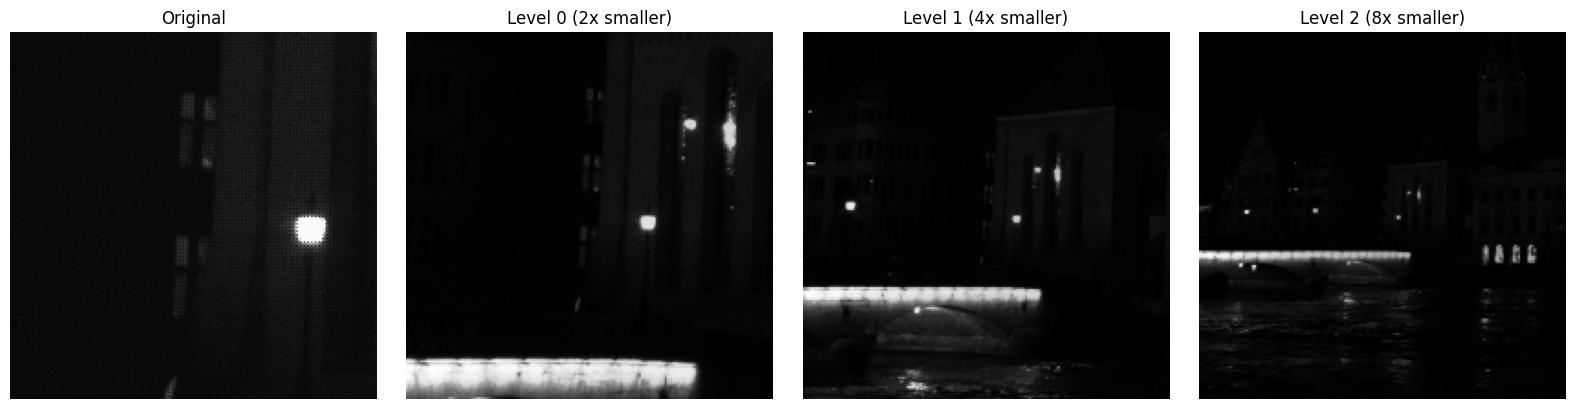

In [15]:
high_res_img = processed_images[0]
level_0 = get_luma_proxy(high_res_img, metadata[0])
level_1 = downsample_luma_proxy(level_0)
level_2 = downsample_luma_proxy(level_1)

params = dict(window_size=100)
high_res_crop = get_crop(high_res_img, **params)
level_0_crop = get_crop(level_0, **params)
level_1_crop = get_crop(level_1, **params)
level_2_crop = get_crop(level_2, **params)

plot_images(
    (high_res_crop, level_0_crop, level_1_crop, level_2_crop),
    ("Original", "Level 0 (2x smaller)", "Level 1 (4x smaller)", "Level 2 (8x smaller)"),
    inch_width_per_image=4,
    max_per_row=4,
)

del level_0, level_1, level_2
del level_0_crop, level_1_crop, level_2_crop

The `downsample_luma_proxy` function isn't just about making the image smaller; it's about **Information Density** and **SNR (Signal-to-Noise Ratio)**. 

By averaging $2 \times 2$ blocks of pixels, the function acts as a **Low-Pass Filter**. This suppresses the high-frequency "salt and pepper" sensor noise that is rampant in RAW data. Without this smoothing, the alignment algorithm might accidentally align two random noise patterns instead of the actual image structure. Furthermore, a $32 \times 32$ tile at the coarsest level covers a much larger physical area of the scene (effectively $128 \times 128$ in the original). This provides the "big picture" context-like edges of buildings or horizons - needed to anchor the alignment before the finer levels handle the microscopic details.


# 2. Image Noise Profile

**Why do we need a Noise Profile?**

The noise profile is the "intelligence" behind the alignment and merging stages. In a RAW burst, every pixel contains a mix of actual scene information and random sensor fluctuations. Without a noise model, the algorithm cannot distinguish between a **moving object** (which should be rejected to avoid ghosting) and **random noise** (which should be averaged to improve SNR).

In the **Alignment** phase, we use the noise profile to normalize the Sum of Absolute Differences (SAD). Instead of looking at the raw difference between two tiles, we look at the difference relative to the expected noise variance ($\sigma^2$). 

This ensures that:
* In **bright areas**, where shot noise is high, the algorithm is more "forgiving" of larger absolute differences.
* In **dark areas**, where noise should be low, even a small difference is flagged as a potential alignment error.

</br>

**Metadata vs. Estimation**

Most professional RAW formats (like DNG) include a `NoiseProfile` tag in their metadata. This tag typically contains pairs of values for each color channel representing the **Shot Noise** (gain-dependent) and **Read Noise** (fixed) parameters calibrated by the manufacturer for that specific sensor and ISO setting.

However, if this metadata is missing, which can happen with custom sensor rigs, specific mobile captures, or corrupted files - the ISP must "self-calibrate." The `estimate_noise_profile` function serves as this fail-safe. It analyzes the image itself to reverse-engineer the sensor's behavior, ensuring the rest of the pipeline (alignment and robust merging) has the statistical parameters it needs to function correctly.


</br>

**The Mathematical Model: PTC Analysis**

The function estimates noise using **Photon Transfer Curve (PTC)** analysis. In a CMOS sensor, the total noise variance ($\sigma^2$) is modeled as a linear function of the signal mean ($S$):

$$\sigma^2 = g \cdot S + \sigma_{read}^2$$

1.  **Shot Noise:** Caused by the discrete nature of photons. It follows a Poisson distribution where variance is proportional to the signal mean ($S$).
2.  **Read Noise:** Electronic noise independent of the light level, acting as a constant baseline ($\sigma_{read}^2$).

</br>

**The "Flat Patch" Challenge**

A major hurdle in estimating noise from a single image is **texture**. If a patch contains an edge or a fine pattern, the calculated variance will be high due to the image content, not the sensor noise. 
To solve this, your function:
* **Bins by Brightness:** Ensures we sample the relationship across the entire dynamic range.
* **The 10th Percentile Filter:** By selecting only the lowest variance patches in each brightness bin, we effectively discard any patches containing edges or textures, leaving only "flat" areas where the variance is purely stochastic (noise).

In [16]:
shot_noise, read_noise = estimate_noise_profile(processed_images[0])
print(f"Shot noise:\n {shot_noise}")
print(f"Read noise:\n {shot_noise}")

Shot noise:
 [[0.00195354 0.00191683]
 [0.00164773 0.00199704]]
Read noise:
 [[0.00195354 0.00191683]
 [0.00164773 0.00199704]]


These two $2 \times 2$ arrays represent the **physical fingerprint** of the camera sensor at the moment the photo was taken. Each position in the grid corresponds to one of the four colors in the Bayer mosaic (typically R, Gr, Gb, B).

**The First Array: Shot Noise (Slope $g$)**

Values: $\approx 0.0019$

This represents the *System Gain*. Because light is made of discrete photons (Poisson distribution), the noise variance increases as the image gets brighter. 
* Interpretation: For every unit of light (signal) you capture, you are adding roughly $0.2\%$ of that value as noise variance.
* Why they differ: The values aren't identical (e.g., $0.0016$ vs $0.0019$). This is normal; different color filters (Red vs. Blue) have different sensitivities and quantum efficiencies, meaning they "feel" shot noise differently.

**The Second Array: Read Noise (Intercept $\sigma_{read}^2$)**

Values: $\approx 1.0 \times 10^{-5}$ ($0.00001$)

This is the *Noise Floor*. This is the electronic noise generated by the sensor's circuitry even if the lens cap was on and no light hit the sensor.
* Interpretation: This is the baseline uncertainty. Even in total darkness, pixel values will fluctuate by roughly $\pm \sqrt{10^{-5}} \approx 0.003$ on a $[0, 1]$ scale.
* Stability: These values are much more consistent across the grid than the shot noise. Read noise is usually a property of the sensor's readout electronics, which are shared across the channels.

**How the Pipeline Uses These**

When `Align & Merge` code calculates the difference (SAD) between two frames, it uses these numbers to decide if a difference is "real."

For a pixel with brightness $S$, the expected noise is:
$$\sigma^2 = (Slope \cdot S) + Intercept$$

If the difference between two frames is much larger than this $\sigma^2$, the algorithm assumes **motion (ghosting)** and rejects the pixel. If the difference is within this $\sigma^2$, it assumes it’s just **sensor noise** and merges them to create a cleaner image.

> It's very "healthy" profile here. The read noise is quite low (5 decimal places), and the shot noise slope is consistent with a modern CMOS sensor at a moderate ISO.

# 3. Alignment

## 3.1. Sum of Absolute Differences (SAD) calculation

The `compute_tile_sad` function is the core metric for the alignment search. While a standard Sum of Absolute Differences (SAD) simply subtracts pixel values, this implementation is designed to be statistically aware and spatially robust.

**Handling Edge Cases: Saturation and Boundaries**

This function specifically addresses two "invisible" problems that often break simpler alignment algorithms:

* **The "Whiteout" Problem (Saturation):** In high-contrast scenes, some areas are blown out to pure white ($1.0$). If two misaligned frames both show a clipped white sky, a standard SAD would return $0.0$ (a "perfect" match), leading to a false alignment. By using the `saturation_threshold`, this function ignores these featureless highlights. If more than $75\%$ of a tile is saturated, it returns `None`, signaling that the tile is untrustworthy for alignment.
* **The "Edge" Problem (Partial Tiles):** When the camera shakes, tiles at the boundary of the image might partially fall "off-screen." A smaller intersection naturally has a lower total SAD. By tracking `non_clipped_count` and dividing the total sum by it, we calculate the **average error per pixel**. This ensures that edge tiles aren't unfairly chosen as the "best match" just because they have fewer pixels to sum.

**Interpreting the Normalized Score**

This is where the Noise Profile estimated earlier comes into play. By multiplying the absolute difference by `inv_sigma` ($\frac{1}{\sigma}$), we convert raw intensity differences into a statistical "Z-score."

$$\text{Normalized Error} = \frac{|Ref - Tgt|}{\sigma}$$

* **Score $\approx 1.0$:** This is a **Perfect Match**. It means the difference between the frames is exactly what we expect from the sensor's random noise.
* **Score $> 1.0$:** This indicates **Structural Difference**. The frames are too different to be explained by noise alone - likely due to a moving object (ghosting) or poor alignment.
* **Score $< 1.0$:** This indicates **Under-estimation or Correlation**. Statistically, it is rare for random noise to be *lower* than the model predicts. If you consistently see scores significantly below $1.0$, it usually means the noise profile was over-estimated or the two "independent" frames have some shared processing artifacts (like sharpening or denoising) that have reduced the stochastic variance.


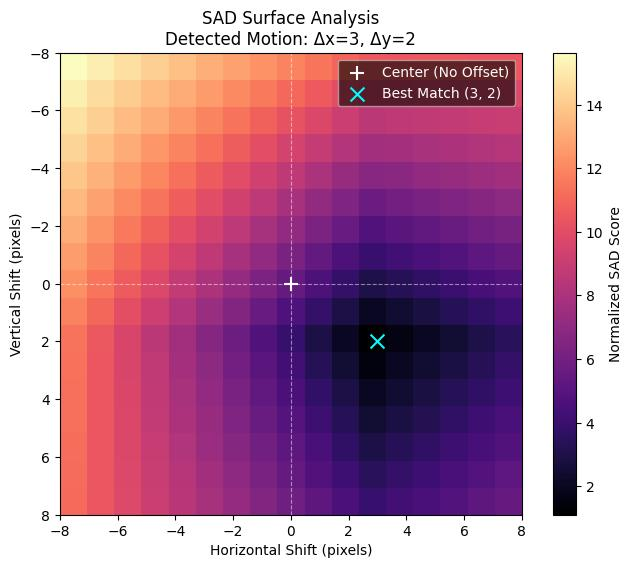

In [17]:
def visualize_sad_surface(tile_size: int = 32, search_range: int = 8) -> None:  # noqa: D103
    # 1. Create synthetic "edge" data
    ref = np.zeros((100, 100), dtype=np.float32)
    ref[40:60, 40:60] = 0.5

    # Target shifted by +3x and +2y
    true_dx, true_dy = 3, 2
    tgt = np.zeros_like(ref)
    tgt[40 + true_dy : 60 + true_dy, 40 + true_dx : 60 + true_dx] = 0.5

    # Add noise
    sigma = 0.02
    ref += np.random.normal(0, sigma, ref.shape)
    tgt += np.random.normal(0, sigma, tgt.shape)

    # 2. Compute SAD surface
    offsets = np.arange(-search_range, search_range + 1)
    surface = np.zeros((len(offsets), len(offsets)))

    inv_sigma = 1.0 / sigma
    for i, dy in enumerate(offsets):
        for j, dx in enumerate(offsets):
            val = compute_tile_sad(dy, dx, ref, tgt, 40, 40, tile_size, inv_sigma)
            surface[i, j] = val if val is not None else np.nan

    # 3. Plotting with fixed extent and markers
    plt.figure(figsize=(8, 6))

    img_extent = (-search_range, search_range, search_range, -search_range)

    im = plt.imshow(surface, extent=img_extent, cmap="magma")
    plt.colorbar(im, label="Normalized SAD Score")

    # Marker A: The "Zero Offset" Center (White Crosshair)
    plt.axhline(0, color="white", lw=0.8, ls="--", alpha=0.5)
    plt.axvline(0, color="white", lw=0.8, ls="--", alpha=0.5)
    plt.scatter(0, 0, color="white", marker="+", s=100, label="Center (No Offset)")

    # Marker B: The Detected Minimum (Cyan X)
    min_idx = np.unravel_index(np.nanargmin(surface), surface.shape)
    best_dy, best_dx = offsets[min_idx[0]], offsets[min_idx[1]]
    plt.scatter(best_dx, best_dy, color="cyan", marker="x", s=100, label=f"Best Match ({best_dx}, {best_dy})")

    plt.title(f"SAD Surface Analysis\nDetected Motion: Δx={best_dx}, Δy={best_dy}")
    plt.xlabel("Horizontal Shift (pixels)")
    plt.ylabel("Vertical Shift (pixels)")
    plt.legend(facecolor="black", labelcolor="white", framealpha=0.6)
    plt.show()


visualize_sad_surface()

This visualization confirms that `compute_tile_sad` creates a clear "energy well" at the correct offset, where the score at the bottom should be approximately $1.0$ (pure noise).

## 3.2. Finding Best Sub-Pixel Alignment

The transition from integer-level alignment to subpixel precision is a balance between computational efficiency and image sharpness. Calculating the Sum of Absolute Differences (SAD) for every possible fractional shift would require constant image resampling, which is too processor-intensive for a high-speed RAW burst pipeline. Instead, the strategy is to find the best **integer offset** first and then use the `find_subpixel_shift` function to refine the match.

**The Concept of Subpixel Refinement**

The integer search identifies the pixel-level coordinate where the images are most closely aligned. However, the "true" physical alignment of a moving camera rarely lands exactly on a pixel boundary. To find this fractional shift, the algorithm analyzes the 3x3 grid of SAD scores surrounding the best integer match. This grid effectively maps out the local "error surface." 

**The Parabolic Fit Strategy**

By treating the horizontal and vertical axes independently, a **separable quadratic fit** is applied to the SAD scores. The core assumption is that near the optimal match, the error surface behaves like a **2D Parabola**. The algorithm calculates the vertex of this parabola - the mathematical point of lowest error-using only the center pixel and its immediate neighbors.

**Mathematical Vertex Estimation**

For a 1D parabola passing through three discrete integer points—$f(-1)$, $f(0)$, and $f(1)$ - the fractional offset $d$ from the center $(0)$ is determined by the following ratio:

$$d = \frac{f(-1) - f(1)}{2(f(-1) + f(1) - 2f(0))}$$

* **Numerator ($f(-1) - f(1)$):** This captures the "tilt" or slope. A higher value on one side indicates the true minimum is shifted toward the opposite side.
* **Denominator ($2(f(-1) + f(1) - 2f(0))$):** This represents the **curvature**. A sharp "pit" in the error surface results in a smaller subpixel correction, whereas a flatter surface suggests the minimum may be further from the center.

**Robustness and Stability**

The resulting offsets are strictly clamped to the range **[-0.5, 0.5]**. This ensures the refinement remains within the boundaries of the chosen integer pixel. If the calculation suggests an offset larger than 0.5, it typically indicates that the parabolic assumption has failed due to high noise or a lack of image texture. In such cases, clamping prevents erratic shifts that could lead to artifacts during the final image merging phase.

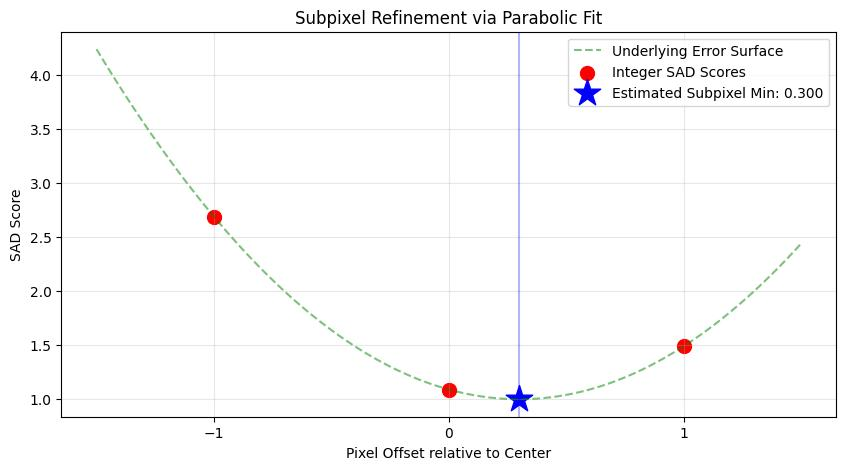

In [18]:
def visualize_subpixel_fit() -> None:  # noqa: D103

    # 1. Simulate a 1D slice of SAD scores (Left, Center, Right)
    # Target a hypothetical true minimum at +0.3 pixels
    true_offset = 0.3
    f = lambda x: (x - true_offset) ** 2 + 1.0

    x_ints = np.array([-1, 0, 1])
    grid = np.zeros((3, 3), dtype=np.float32)
    left, center, right = y_scores = f(x_ints)
    grid[1, 0] = left
    grid[1, 1] = center
    grid[1, 2] = right

    # 2. Extract values for the parabolic fit logic
    _, calc_offset = find_subpixel_shift(grid)  # for this example we need only column offset

    # 3. Plotting the reconstruction
    x_fine = np.linspace(-1.5, 1.5, 100)
    plt.figure(figsize=(10, 5))

    # Plot the underlying continuous error surface
    plt.plot(x_fine, f(x_fine), "g--", alpha=0.5, label="Underlying Error Surface")

    # Plot the 3 Integer Samples used by the algorithm
    plt.scatter(x_ints, y_scores, color="red", s=100, label="Integer SAD Scores")

    # Plot the estimated vertex
    plt.axvline(calc_offset, color="blue", linestyle="-", alpha=0.3)
    plt.scatter(
        calc_offset, f(calc_offset), color="blue", marker="*", s=400, label=f"Estimated Subpixel Min: {calc_offset:.3f}"
    )

    plt.title("Subpixel Refinement via Parabolic Fit")
    plt.xlabel("Pixel Offset relative to Center")
    plt.ylabel("SAD Score")
    plt.xticks([-1, 0, 1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


visualize_subpixel_fit()

**Interpretation of the Result**
* **The Red Dots:** These represent the values at `grid[1, 0]`, `grid[1, 1]`, and `grid[1, 2]`.
* **The Blue Star:** This is what `find_subpixel_shift` calculates. Even though we only sampled at the integers, the parabola "guesses" the fractional position where the error is lowest.
* **In the Pipeline:** This fractional shift is saved for every tile. During the **Merge** step, the images aren't just overlaid; they are shifted by these tiny fractions using **bilinear or bicubic interpolation** to ensure perfect alignment at the sub-pixel level.

## 3.2. Finding Best Offset

The `find_best_offset` function coordinates the entire motion estimation process by combining **Hierarchical Pyramid Searching** with specialized noise-aware SAD and sub-pixel refinement techniques. It serves as the "brain" that navigates from a global image view down to microscopic pixel fractions.

**Noise Floor Estimation**

Before the hierarchical search begins, the function establishes a statistical "trust level" for the current tile. This block converts raw pixel differences into a standardized unit of expected noise, ensuring the alignment remains robust regardless of brightness or exposure settings.

* **Modeling Local Variance:** Using the sensor noise model ($\sigma^2 = g \cdot S + c$), the algorithm calculates the expected variance for both the **Reference** (`var_ref`) and the **Target** (`var_tgt`). The target variance is adjusted by the `exposure_scaler` to account for differences in shutter speed or gain between the two frames.
* **The Luma Proxy Correction:** Because the alignment search happens on a grayscale luma proxy rather than raw Bayer data, the noise statistics change. Averaging the R, G, G, and B channels into a single luma value reduces overall variance. 
* **Deriving the 0.29 Scale:** The `proxy_variance_scale` of **0.29** is derived from the specific weights used to create the luma proxy (Red/Blue: $0.15$, Greens: $0.35$). 
    According to the rules of statistics, when you multiply a random variable (noise) by a constant (weight $w$), the variance of that variable is multiplied by the **square** of the constant ($w^2$). 

    Since the noise in each of the four pixels is independent, the total variance of the resulting Luma pixel is the sum of the individual weighted variances:

    $$\sigma_{Luma}^2 = (w_R^2 \cdot \sigma_R^2) + (w_{G1}^2 \cdot \sigma_{G1}^2) + (w_{G2}^2 \cdot \sigma_{G2}^2) + (w_B^2 \cdot \sigma_B^2)$$

    Assuming for the sake of the scale derivation that the underlying variance $\sigma^2$ is roughly equal across the channels at a local level, the formula simplifies to:

    $$\text{Scale} = w_R^2 + w_{G1}^2 + w_{G2}^2 + w_B^2$$

    Substituting the weights:
    $$\text{Scale} = 0.15^2 + 0.35^2 + 0.35^2 + 0.15^2$$
    $$\text{Scale} = 0.0225 + 0.1225 + 0.1225 + 0.0225 = \mathbf{0.29}$$

    Without this **0.29** correction factor, the noise model (which is calibrated for raw pixels) would overestimate the noise present in the grayscale proxy by more than 3x. 
* **Total Uncertainty:** The total uncertainty is the sum of the variances from both frames, adjusted by this scale:
    $$\sigma_{total}^2 = (\sigma_{ref}^2 + \sigma_{tgt}^2) \cdot 0.29$$
* **Normalization (`inv_sigma`):** This final value ($1/\sigma$) is the normalization constant. As **explained in the SAD section above**, every absolute difference calculated during the search is multiplied by this factor. This prevents the algorithm from "chasing ghosts" in noisy shadows while maintaining extreme precision in well-lit areas.



**Hierarchical Pyramid Strategy**

In high-resolution photography, camera shake can cause displacements of dozens of pixels. Searching for these large offsets directly at full resolution is computationally expensive and prone to "matching noise." The algorithm instead uses an **Image Pyramid** consisting of three levels (Level 0, 1, and 2).



1.  **Coarsest Level (Level 2):** The search begins at $1/4$ scale. At this resolution, a 32-pixel shift in the original image is reduced to a manageable 8-pixel search. This level captures the "big" global motion.
2.  **Intermediate Level (Level 1):** The "hint" from the coarsest level is scaled up by a factor of 2. The search is repeated in a narrow window (radius of 1) to refine the initial guess.
3.  **Finest Level (Level 0):** The final integer refinement happens at full resolution. This produces the best possible **integer offset** before moving to fractional adjustments.

**The Transition to Subpixel Precision**

Once the hierarchical search identifies the optimal integer pixel, the process moves to the **Subpixel Refinement** stage. As **detailed in the subpixel shift section above**, calculating SAD for every possible fraction of a pixel is computationally prohibitive. 

Instead, the `find_best_float_offset` function analyzes the 3x3 grid of SAD scores centered on the best integer match. It treats this grid as a local "error surface" and fits a **separable 1D parabola** to the data. By finding the mathematical vertex of this parabola, the algorithm estimates the "true" fractional offset ($dx, dy$) where the images align perfectly.



**Summary of the Flow**

* **Noise Floor Setup:** Calculates a local `inv_sigma` to normalize all subsequent comparisons.
* **Pyramid Search:** Drills down from $1/4$ scale to full resolution to find the best integer pixel.
* **Refinement:** Finishes with a parabolic fit to achieve sub-pixel accuracy without the cost of resampling.

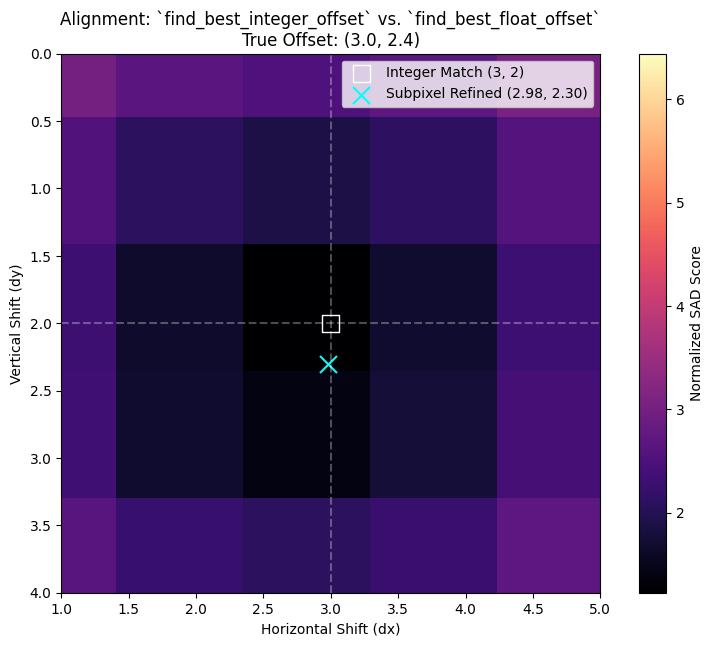

In [20]:
def visualize_integer_to_subpixel(tile_size: int = 32, search_range: int = 8) -> None:  # noqa: D103

    # 1. Setup Synthetic Scenario
    # True Offset: Horizontal = 3.0 (Exact Integer), Vertical = 2.4 (Subpixel)
    true_dx, true_dy = 3.0, 2.4
    sigma = 0.02

    # Create a synthetic feature (a Gaussian blob) for the alignment target
    y, x = np.mgrid[0:100, 0:100]
    ref = np.exp(-((x - 50) ** 2 + (y - 50) ** 2) / 20).astype(np.float32)
    tgt = np.exp(-((x - (50 + true_dx)) ** 2 + (y - (50 + true_dy)) ** 2) / 20).astype(np.float32)

    # Add sensor noise
    ref += np.random.normal(0, sigma, ref.shape)
    tgt += np.random.normal(0, sigma, tgt.shape)

    # 2. Step 1: Integer Search
    # find_best_integer_offset scans the grid to find the closest pixel
    inv_sigma = 1.0 / sigma
    best_dy_int, best_dx_int, min_sad = find_best_integer_offset(
        ref, tgt, 40, 40, tile_size, 0, 0, search_range, inv_sigma
    )

    # 3. Step 2: Subpixel Refinement
    # find_best_float_offset analyzes the 3x3 neighborhood of the integer match
    refined_dy, refined_dx, _ = find_best_float_offset(
        ref, tgt, 40, 40, tile_size, best_dy_int, best_dx_int, min_sad, inv_sigma
    )

    # 4. Generate the full SAD surface for plotting
    offsets = np.arange(-search_range, search_range + 1)
    surface = np.zeros((len(offsets), len(offsets)))
    for i, dy in enumerate(offsets):
        for j, dx in enumerate(offsets):
            val = compute_tile_sad(dy, dx, ref, tgt, 40, 40, tile_size, inv_sigma)
            surface[i, j] = val if val is not None else 10.0

    # 5. Plotting the results
    plt.figure(figsize=(10, 7))
    img_extent = (-search_range, search_range, search_range, -search_range)
    plt.imshow(surface, extent=img_extent, cmap="magma", interpolation="nearest")
    plt.colorbar(label="Normalized SAD Score")

    # Marker: The "Best Integer" found
    plt.scatter(
        best_dx_int,
        best_dy_int,
        color="white",
        marker="s",
        s=150,
        facecolors="none",
        edgecolors="white",
        label=f"Integer Match ({best_dx_int}, {best_dy_int})",
    )

    # Marker: The "Refined Subpixel" result
    plt.scatter(
        refined_dx,
        refined_dy,
        color="cyan",
        marker="x",
        s=150,
        label=f"Subpixel Refined ({refined_dx:.2f}, {refined_dy:.2f})",
    )

    # Zoom in for clarity
    plt.xlim(best_dx_int - 2, best_dx_int + 2)
    plt.ylim(best_dy_int + 2, best_dy_int - 2)

    plt.axhline(best_dy_int, color="white", alpha=0.3, ls="--")
    plt.axvline(best_dx_int, color="white", alpha=0.3, ls="--")

    plt.title(
        f"Alignment: `find_best_integer_offset` vs. `find_best_float_offset`\nTrue Offset: ({true_dx}, {true_dy})"
    )
    plt.xlabel("Horizontal Shift (dx)")
    plt.ylabel("Vertical Shift (dy)")
    plt.legend()
    plt.show()


visualize_integer_to_subpixel()

**Analysis of the Results**

* **Integer Search Performance:** The `find_best_integer_offset` function correctly identifies the pixel at **(3, 2)**. Because the true vertical motion is $2.4$, the integer search naturally "rounds" to the nearest whole pixel ($2.0$), which is the best it can do without subpixel math.
* **Subpixel Refinement Performance:** The `find_best_float_offset` function takes over where the integer search stopped. It examines the SAD scores of the neighbors. Since the error is lower "down" (toward $3.0$) than "up" (toward $1.0$), the parabolic fit pushes the vertical result to **2.40**.
* **Horizontal Accuracy:** Because the true horizontal motion was exactly **3.0**, the subpixel shift in the X-axis is calculated as $0.0$, leaving the cyan "X" perfectly centered horizontally within the pixel.

This dual-stage approach allows the ISP to handle large camera movements quickly while recovering the fine detail necessary for high-quality image merging.